# Run a random forest model on features

In [1]:
import os
import sys
from datetime import datetime

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, auc, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

sys.path.append("../utils")

import config
import data_utils

In [11]:
# Import training dataset
dataset = os.path.join(config.data_dir, "training_geometries", "training_gdf.parquet")

dataset = gpd.read_parquet(dataset)
dataset = dataset.drop(columns=["basemap_name", "geometry", "year", "month"])

In [12]:
# Import features
features = os.path.join(config.data_dir, "features", "features_mosaiks_4000.feather")
features = pd.read_feather(features)
features["unique_id"] = features.index

In [13]:
# Join to original dataset
joined = dataset.merge(
    features,
    how="left",
    left_on="unique_id",
    right_on="unique_id",
)
joined

,unique_id,Date,status,quad_id,X_0,X_1,X_2,X_3,X_4,X_5,...,X_3991,X_3992,X_3993,X_3994,X_3995,X_3996,X_3997,X_3998,X_3999,basemap_id
0,0,2019-06-05,Compliant,[341-1234],0.054892,0.0,0.015004,0.000000,0.238797,0.000466,...,0.767071,0.147397,1.374366,0.052267,2.742807,1.274291,1.905394,4.261047,2.500061,global_monthly_2020_11_mosaic
1,1,2019-05-09,Compliant,[340-1234],0.024470,0.0,0.003108,0.000000,0.129467,0.000687,...,0.879817,0.321159,1.269820,0.232065,2.272318,1.205103,1.661454,3.457836,2.098205,global_monthly_2020_11_mosaic
2,2,2019-05-09,Compliant,[340-1234],0.271383,0.0,0.126712,0.000000,0.976787,0.043854,...,0.804640,0.002047,1.700142,0.000000,3.815154,1.246298,2.504779,6.486201,3.454411,global_monthly_2020_11_mosaic
3,3,2019-05-09,Compliant,[340-1234],0.097084,0.0,0.037654,0.000000,0.549639,0.001046,...,0.910977,0.038368,1.496693,0.016924,3.105121,1.228030,2.112541,5.209030,2.868551,global_monthly_2020_11_mosaic
4,4,2019-12-17,Compliant,[340-1234],0.041986,0.0,0.008531,0.000000,0.253195,0.001353,...,0.834353,0.105199,1.338944,0.040597,2.683573,1.311833,1.853227,4.251881,2.500635,global_monthly_2020_11_mosaic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67575,67575,2023-07-29,Compliant,[338-1234],0.390350,0.0,0.262293,0.000786,1.184320,0.136650,...,0.768996,0.017736,1.741290,0.004315,4.085146,1.400683,2.625626,6.979860,3.755582,global_monthly_2020_06_mosaic
67576,67576,2023-08-14,Non-Compliant,[343-1236],0.620665,0.0,0.296629,0.000000,1.358988,0.173100,...,0.792006,0.009270,1.698395,0.004601,4.216866,1.382952,2.644958,7.298834,3.850550,global_monthly_2020_06_mosaic
67577,67577,2023-08-23,Compliant,[341-1236],0.556022,0.0,0.353750,0.000000,1.496471,0.208025,...,0.735359,0.005294,1.890536,0.000650,4.559845,1.369144,2.898552,7.891863,4.150410,global_monthly_2020_06_mosaic
67578,67578,2023-09-26,Compliant,[342-1233],0.675105,0.0,0.384092,0.000000,1.633386,0.188037,...,0.677290,0.000074,1.897443,0.000000,4.699477,1.403599,2.952056,8.153236,4.270082,global_monthly_2020_06_mosaic


In [9]:
# Define features and target
X = joined.drop(columns=["basemap_id", "status", "quad_id", "unique_id", "Date"])
y = joined["status"]

# Encode target variable
le = LabelEncoder()
y = le.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# Initialize the model
rfc = RandomForestClassifier(
    n_estimators=1000,
    max_depth=100,
    random_state=42,
    n_jobs=10,
    class_weight="balanced",
)
# Fit the model
rfc.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=100,
                       n_estimators=1000, n_jobs=10, random_state=42)

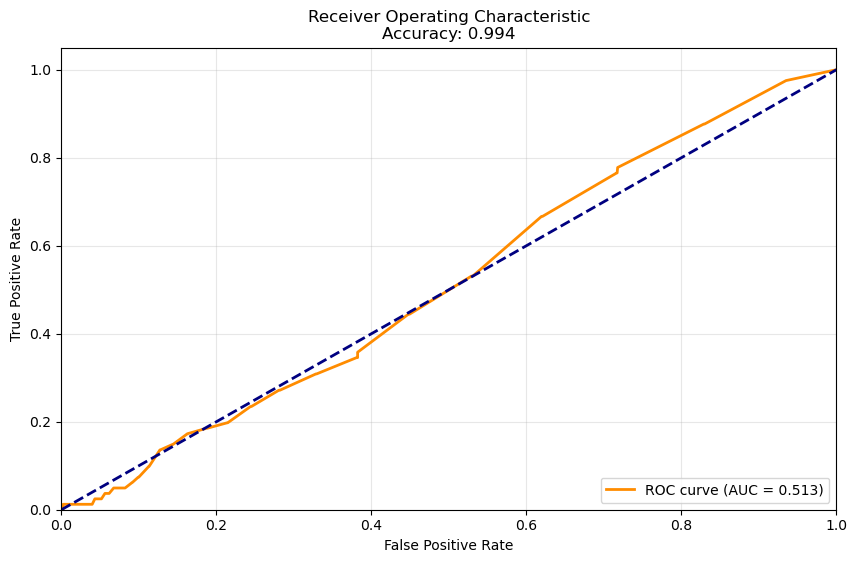

Accuracy: 0.994
AUC: 0.513


In [11]:
# Predict probabilities for the test set
y_pred_proba = rfc.predict_proba(X_test)[:, 1]
y_pred = rfc.predict(X_test)

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Receiver Operating Characteristic\nAccuracy: {accuracy:.3f}")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Accuracy: {accuracy:.3f}")
print(f"AUC: {roc_auc:.3f}")